In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import Tuple

def correlation(img1: np.ndarray, img2: np.ndarray) -> float:
    f = img1.flatten()
    g = img2.flatten()
    n = f.size
    mu_f = np.mean(f)
    mu_g = np.mean(g)
    sigma_f = np.std(f)
    sigma_g = np.std(g)
    return np.sum((f - mu_f) * (g - mu_g)) / (n * sigma_f * sigma_g)

img1 = cv2.imread('data/barton2-small.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('data/barton2-window.jpg', cv2.IMREAD_GRAYSCALE)
corr_value = correlation(img1[0:img2.shape[0], 0:img2.shape[1]], img2)
print("Correlation between patch and template:", corr_value)

Correlation between patch and template: 0.14770175607122155


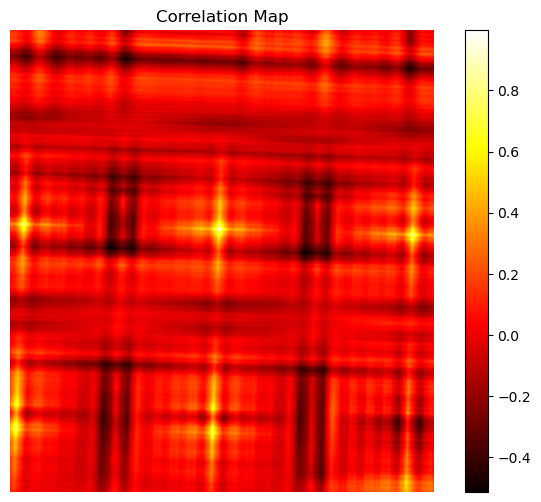

In [7]:
def get_correlation_map(img: np.ndarray, template: np.ndarray) -> np.ndarray:
    h, w = template.shape
    H, W = img.shape
    corr_map = np.zeros((H - h + 1, W - w + 1))
    for i in range(H - h + 1):
        for j in range(W - w + 1):
            patch = img[i:i+h, j:j+w]
            corr_map[i, j] = correlation(patch, template)
    return corr_map

corr_map = get_correlation_map(img1, img2)
plt.figure(figsize=(8,6))
plt.imshow(corr_map, cmap='hot')
plt.colorbar()
plt.title('Correlation Map')
plt.axis('off')
plt.show()

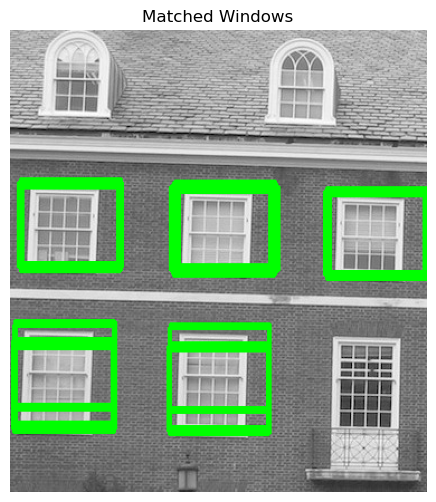

In [8]:
def find_matched(image: np.ndarray, corr_map: np.ndarray, template_size: Tuple[int, int], threshold: float) -> np.ndarray:
    result = image.copy()
    h, w = template_size
    ys, xs = np.where(corr_map > threshold)
    for (y, x) in zip(ys, xs):
        cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return result

matched_img = find_matched(cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR), corr_map, img2.shape[::-1], threshold=0.6)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title('Matched Windows')
plt.axis('off')
plt.show()

In [9]:
def IoU(box1, box2) -> float:
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)
    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = area1 + area2 - inter_area
    return inter_area / union_area if union_area != 0 else 0

box_a = (50, 50, 150, 150)
box_b = (100, 100, 200, 200)
print("IoU between two boxes:", IoU(box_a, box_b))

IoU between two boxes: 0.14285714285714285


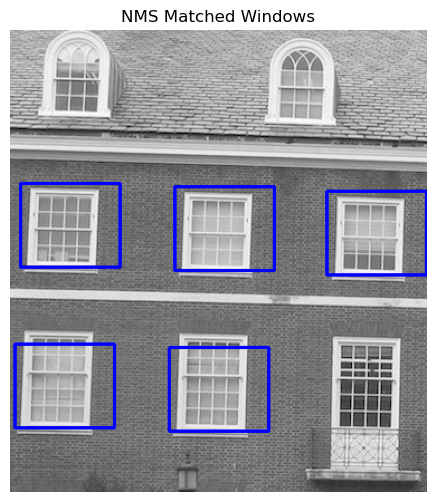

In [10]:
def non_max_suppression(boxes, scores, iou_threshold: float):
    idxs = np.argsort(scores)[::-1]
    selected_boxes = []
    while len(idxs) > 0:
        current = idxs[0]
        selected_boxes.append(current)
        remove_idxs = [0]
        for i in range(1, len(idxs)):
            if IoU(boxes[current], boxes[idxs[i]]) > iou_threshold:
                remove_idxs.append(i)
        idxs = np.delete(idxs, remove_idxs)
    return selected_boxes

def nms_find_matched(image: np.ndarray, corr_map: np.ndarray, template_size: Tuple[int, int], threshold: float, iou_threshold: float = 0.5) -> np.ndarray:
    result = image.copy()
    h, w = template_size
    ys, xs = np.where(corr_map > threshold)
    boxes = [(x, y, x + w, y + h) for (y, x) in zip(ys, xs)]
    scores = [corr_map[y, x] for (y, x) in zip(ys, xs)]
    selected_idxs = non_max_suppression(boxes, scores, iou_threshold)
    for idx in selected_idxs:
        x1, y1, x2, y2 = boxes[idx]
        cv2.rectangle(result, (x1, y1), (x2, y2), (255, 0, 0), 2)
    return result

nms_matched_img = nms_find_matched(cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR), corr_map, img2.shape[::-1], threshold=0.6, iou_threshold=0.3)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(nms_matched_img, cv2.COLOR_BGR2RGB))
plt.title('NMS Matched Windows')
plt.axis('off')
plt.show()

C:\Users\duy68\AppData\Local\Temp\ipykernel_13912\4266514726.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.sum((f - mu_f) * (g - mu_g)) / (n * sigma_f * sigma_g)


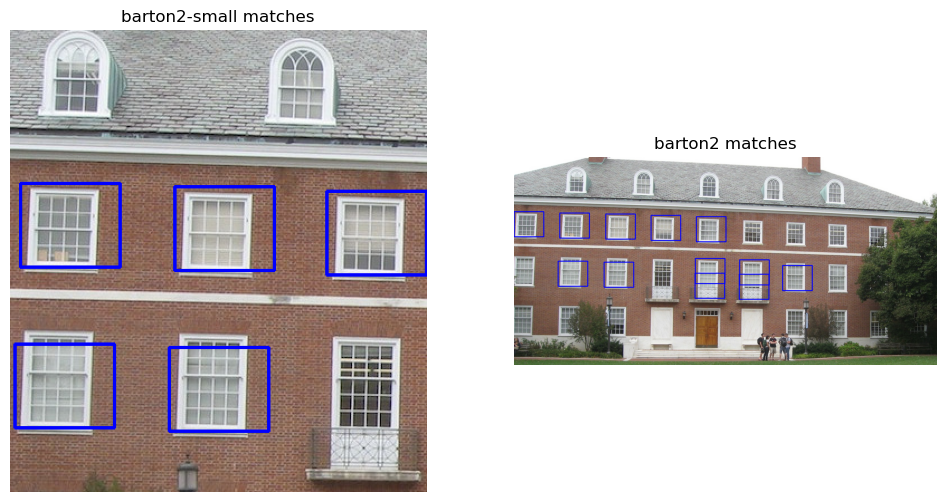

In [11]:
def main():
    img_small = cv2.imread('data/barton2-small.jpg')
    img_full = cv2.imread('data/barton2.jpg')
    template = cv2.imread('data/barton2-window.jpg')
    img_small_gray = cv2.cvtColor(img_small, cv2.COLOR_BGR2GRAY)
    img_full_gray = cv2.cvtColor(img_full, cv2.COLOR_BGR2GRAY)
    template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
    corr_map_small = get_correlation_map(img_small_gray, template_gray)
    matched_img_small = nms_find_matched(img_small, corr_map_small, template_gray.shape[::-1], threshold=0.6, iou_threshold=0.3)
    corr_map_full = get_correlation_map(img_full_gray, template_gray)
    matched_img_full = nms_find_matched(img_full, corr_map_full, template_gray.shape[::-1], threshold=0.6, iou_threshold=0.3)
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(matched_img_small, cv2.COLOR_BGR2RGB))
    plt.title('barton2-small matches')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(matched_img_full, cv2.COLOR_BGR2RGB))
    plt.title('barton2 matches')
    plt.axis('off')
    plt.show()

main()